In [1]:
place_names = [
    {"name": "Elephant Is.", "lon": 302, "lat": -61.2, "orig_lon": 302, "orig_lat": -61.2, "ha": "center", "va": "bottom", "angle": 270},
    {"name": "Joinville Is.", "lon": 305, "lat": -62.5, "orig_lon": 305, "orig_lat": -62.5, "ha": "center", "va": "bottom", "angle": 90},
    {"name": "Boyd St.", "lon": 299, "lat": -63, "orig_lon": 299, "orig_lat": -63, "ha": "center", "va": "top", "angle": 270},
    {"name": "Anvers Is.", "lon": 297, "lat": -64.8, "orig_lon": 297, "orig_lat": -64.8, "ha": "center", "va": "top", "angle": 270},
    {"name": "Adelaide Is.", "lon": 293, "lat": -67.1, "orig_lon": 293, "orig_lat": -67.1, "ha": "center", "va": "top", "angle": 270},
    {"name": "Alexander Is.", "lon": 285, "lat": -71, "orig_lon": 285, "orig_lat": -71, "ha": "center", "va": "top", "angle": 270}
]

In [41]:
def plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names, box_zorder=6, label_fontsize=12, place_fontsize=10):
    """
    Plot nurseries with bounding boxes, labels, and additional sea and place names.

    Parameters:
        ax (matplotlib.axes): The matplotlib axis to plot on.
        extent (list): The extent of the map in [lon_min, lon_max, lat_min, lat_max].
        locations (dict): Dictionary of locations with bounding boxes.
        location_labels (dict): Human-readable labels for locations.
        location_order (dict): Order for locations.
        sea_names (list): List of sea names with coordinates and labels.
        place_names (list): List of place names with coordinates and labels.
        box_zorder (int): Z-order for the boxes.
        label_fontsize (int): Font size for nursery and sea labels.
        place_fontsize (int): Font size for place names.
    """
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Plot nurseries with labels
    for region in sorted(locations.keys(), key=lambda x: location_order[x]):
        for box in locations[region]['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            
            # Plot bounding box
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)
            
            # Calculate centroid for label
            lon_center = np.mean(lonpoly)
            lat_center = np.mean(latpoly)
            
            # Add the label at the centroid with white outline
            text = ax.text(
                lon_center, lat_center, f"{location_labels.get(region, region)}\nNG", 
                fontsize=label_fontsize, color='black', ha='center', va='center',
                transform=ccrs.PlateCarree(), zorder=box_zorder + 1
            )
            # Add white outline to text
            text.set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ])

    # Plot sea names
    for sea in sea_names:
        ax.text(
            sea['lon'], sea['lat'], sea['name'], 
            fontsize=label_fontsize, color='black', ha=sea.get('ha', 'center'), va=sea.get('va', 'center'),
            transform=ccrs.PlateCarree(), zorder=box_zorder + 1,
            path_effects=[
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ]
        )

    # Plot place names with lines
    for place in place_names:
        label_lon = place['lon'] - 1  # Adjust label position slightly to the left
        label_lat = place['lat']

        # Draw a line connecting the place point to the label
        ax.plot([place['lon'], label_lon], [place['lat'], label_lat], 
                color='black', linewidth=0.5, transform=ccrs.PlateCarree(), zorder=box_zorder)

        # Add the place name label
        ax.text(
            label_lon, label_lat, place['name'], 
            fontsize=place_fontsize, color='black', ha=place.get('ha', 'right'), va=place.get('va', 'center'),
            transform=ccrs.PlateCarree(), zorder=box_zorder + 1,
            path_effects=[
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ]
        )

In [40]:
sea_names = [
    {"name": "WEDDELL SEA", "lon": 315, "lat": -64, "ha": "center", "va": "center"},
    {"name": "BELLINGSHAUSEN SEA", "lon": 280, "lat": -63, "ha": "center", "va": "center"}
]

place_names = [
    {"name": "Elephant Is.", "lon": 302, "lat": -61.2, "ha": "center", "va": "bottom"},
    {"name": "Joinville Is.", "lon": 305, "lat": -62.5, "ha": "center", "va": "bottom"},
    {"name": "Boyd St.", "lon": 299, "lat": -63, "ha": "center", "va": "top"},
    {"name": "Anvers Is.", "lon": 297, "lat": -64.8, "ha": "center", "va": "top"},
    {"name": "Adelaide Is.", "lon": 293, "lat": -67.1, "ha": "center", "va": "top"},
    {"name": "Alexander Is.", "lon": 285, "lat": -71, "ha": "center", "va": "top"}
]

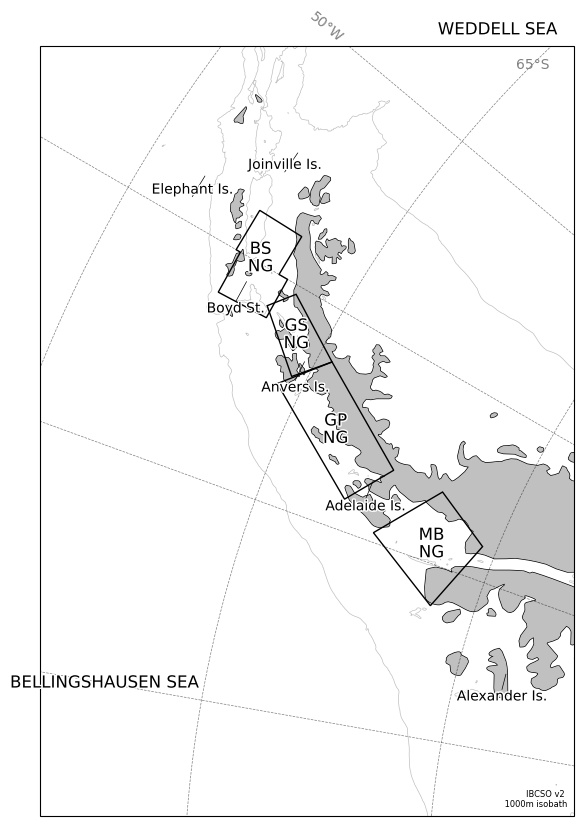

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
extent = [275, 310, -68, -62]

plot_region(ax, extent)  # Adds coastline, land, and gridlines
plot_contour(ax, extent)  # Adds bathymetry contours

plot_reference_map_with_labels(ax, extent, locations, location_labels, location_order, sea_names, place_names)

plt.show()

# TEST PLACE NAME LOCATIONS


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Polygon
from matplotlib import patheffects
import utils  # Your utility functions for plotting, extents, etc.

# Define helper functions
from shapely.geometry import Point, Polygon as ShapelyPolygon

# Extent and other map settings
extent = [275, 310, -68, -62]

In [132]:
sea_names = [
    {"name": "WEDDELL SEA", "lon": 315, "lat": -64, "orig_lon": 315, "orig_lat": -64,  "ha": "center", "va": "center"},
    {"name": "BELLINGSHAUSEN SEA", "lon": 280, "lat": -63, "orig_lon": 280, "orig_lat": 63,  "ha": "center", "va": "center"}
]

place_names = [
    {"name": "Elephant Is.", "lon": 302, "lat": -61.2, "orig_lon": 302, "orig_lat": -61.2, "ha": "center", "va": "bottom"},
    {"name": "Joinville Is.", "lon": 305, "lat": -62.5, "orig_lon": 305, "orig_lat": -62.5, "ha": "center", "va": "bottom"},
    {"name": "Boyd St.", "lon": 299, "lat": -63, "orig_lon": 299, "orig_lat": -63, "ha": "center", "va": "top"},
    {"name": "Anvers Is.", "lon": 297, "lat": -64.8, "orig_lon": 297, "orig_lat": -64.8, "ha": "center", "va": "top"},
    {"name": "Adelaide Is.", "lon": 293, "lat": -67.1, "orig_lon": 293, "orig_lat": -67.1, "ha": "center", "va": "top"},
    {"name": "Alexander Is.", "lon": 285, "lat": -71, "orig_lon": 285, "orig_lat": -71, "ha": "center", "va": "top"}
]

In [126]:
def plot_reference_map_with_debug_dots(ax, extent, locations, location_labels, location_order, sea_names, place_names):
    """
    Plot nurseries, sea names, and place names with debugging dots for both original and adjusted values.

    Parameters:
        ax (matplotlib.axes): Matplotlib axis object.
        extent (list): Map extent [lon_min, lon_max, lat_min, lat_max].
        locations, location_labels, location_order: Nursery data.
        sea_names (list): List of sea names with lon/lat.
        place_names (list): List of place names with lon/lat.
    """
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Plot nurseries
    for region in sorted(locations.keys(), key=lambda x: location_order[x]):
        for box in locations[region]['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', transform=ccrs.PlateCarree())
            ax.add_patch(poly)

    # Legend tracking flags
    original_added = False
    adjusted_added = False

    # Plot sea names with debugging dots for both original and adjusted
    for sea in sea_names:
        label_lon = sea['lon'] - 1  # Adjust slightly left
        ax.plot([sea['lon'], label_lon], [sea['lat'], sea['lat']], color='black', linewidth=0.5, transform=ccrs.PlateCarree())
        ax.text(
            label_lon, sea['lat'], sea['name'], fontsize=10, ha='right', va=sea['va'], transform=ccrs.PlateCarree(),
            path_effects=[patheffects.Stroke(linewidth=2, foreground='white'), patheffects.Normal()]
        )
        # Add blue dot for original position
        if not original_added:
            ax.plot(sea['orig_lon'], sea['orig_lat'], 'bo', label='Original', transform=ccrs.PlateCarree(), zorder=10)
            original_added = True
        else:
            ax.plot(sea['orig_lon'], sea['orig_lat'], 'bo', transform=ccrs.PlateCarree(), zorder=10)

        # Add red dot for adjusted position
        if not adjusted_added:
            ax.plot(sea['lon'], sea['lat'], 'ro', label='Adjusted', transform=ccrs.PlateCarree(), zorder=10)
            adjusted_added = True
        else:
            ax.plot(sea['lon'], sea['lat'], 'ro', transform=ccrs.PlateCarree(), zorder=10)

    # Plot place names with debugging dots for both original and adjusted
    for place in place_names:
        label_lon = place['lon'] - 1  # Adjust slightly left
        ax.plot([place['lon'], label_lon], [place['lat'], place['lat']], color='black', linewidth=0.5, transform=ccrs.PlateCarree())
        ax.text(
            label_lon, place['lat'], place['name'], fontsize=10, ha='right', va=place['va'], transform=ccrs.PlateCarree(),
            path_effects=[patheffects.Stroke(linewidth=2, foreground='white'), patheffects.Normal()]
        )
        # Add blue dot for original position
        if not original_added:
            ax.plot(place['orig_lon'], place['orig_lat'], 'bo', label='Original', transform=ccrs.PlateCarree(), zorder=10)
            original_added = True
        else:
            ax.plot(place['orig_lon'], place['orig_lat'], 'bo', transform=ccrs.PlateCarree(), zorder=10)

        # Add red dot for adjusted position
        if not adjusted_added:
            ax.plot(place['lon'], place['lat'], 'ro', label='Adjusted', transform=ccrs.PlateCarree(), zorder=10)
            adjusted_added = True
        else:
            ax.plot(place['lon'], place['lat'], 'ro', transform=ccrs.PlateCarree(), zorder=10)

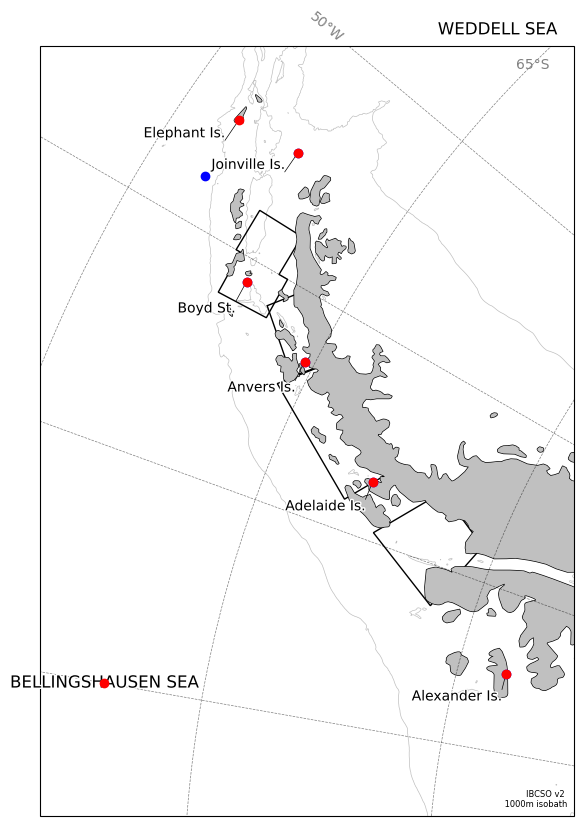

In [72]:
# Example: Test coordinates with debugging dots
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
extent = [275, 310, -68, -62]

# Plot base map and debugging dots
plot_region(ax, extent)  # Base map with coastlines, land, and gridlines
plot_contour(ax, extent)  # Add bathymetry contours
plot_reference_map_with_debug_dots(ax, extent, locations, location_labels, location_order, sea_names, place_names)

plt.show()

Reference for Adjusting Coordinates

1.	Latitude (lat):

    • Increase the lat → Moves the label north (toward the equator).

    • Decrease the lat → Moves the label south (toward the pole).

3.	Longitude (lon):

	•	Increase the lon → Moves the label east.

	•	Decrease the lon → Moves the label west.

In [77]:
# Adjust specific coordinates
for place in place_names:
    if place['name'] == "Elephant Is.":
        place['lon'] += 2.7  # Move east
        place['lat'] += 0.05  # Move north

In [134]:
# Reset coordinates to original before making adjustments
for place in place_names:
    place['lon'] = place['orig_lon']
    place['lat'] = place['orig_lat']

# Adjust specific coordinates
for place in place_names:
    if place['name'] == "Elephant Is.":
        place['lon'] += 2.7  # Move east
        place['lat'] += 0.05  # Move north

    if place['name'] == "Joinville Is.":
        place['lon'] += -.4  # Move west
        place['lat'] += -0.75  # Move south

    if place['name'] == "Boyd St.":
        place['lon'] += -.7  # Move west
        place['lat'] += -0.2  # Move south

    if place['name'] == "Anvers Is.":
        place['lon'] += -.7  # Move west
        place['lat'] += 0.2  # Move north

    if place['name'] == "Adelaide Is.":
        place['lon'] += -1.35  # Move west
        place['lat'] += -0.1  # Move south

    if place['name'] == "Alexander Is.":
        place['lon'] += 3.5  # Move east
        place['lat'] += 1.9  # Move north

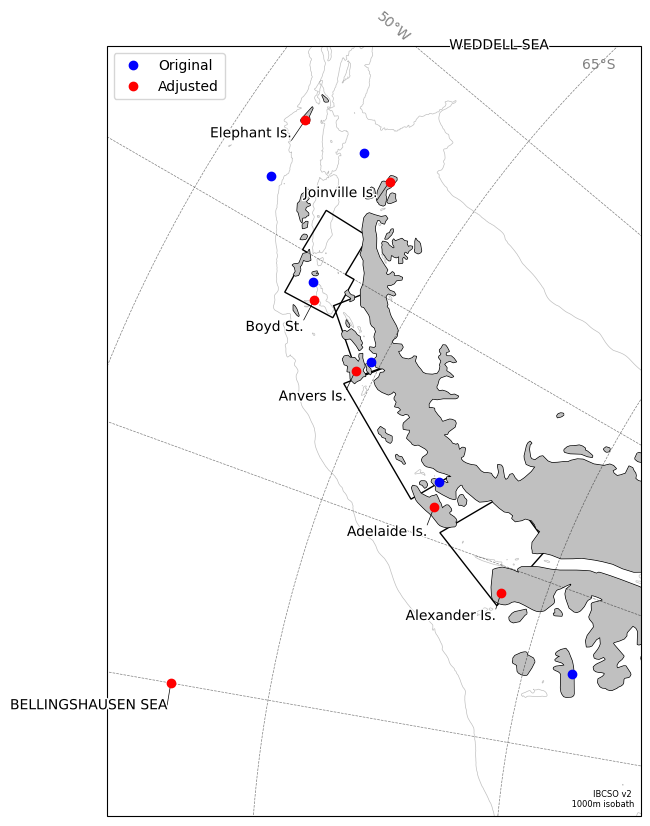

In [135]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_region(ax, extent)
plot_contour(ax, extent)
plot_reference_map_with_debug_dots(ax, extent, locations, location_labels, location_order, sea_names, place_names)
plt.legend(loc='upper left')  # Add the legend outside the map
plt.show()

In [ ]:
sea_names = [
    {"name": "WEDDELL SEA", "lon": 315, "lat": -64, "orig_lon": 315, "orig_lat": -64, "ha": "center", "va": "center"},
    {"name": "BELLINGSHAUSEN SEA", "lon": 280, "lat": -63, "orig_lon": 280, "orig_lat": -63, "ha": "center", "va": "center"}
]

In [2]:
# Reset coordinates to original before making adjustments
for sea in sea_names:
    sea['lon'] = sea['orig_lon']
    sea['lat'] = sea['orig_lat']

# Adjust specific coordinates
for sea in sea_names:
    if sea['name'] == "WEDDELL SEA":
        sea['lon'] += -5  # Move west
        sea['lat'] += -3  # Move south

    if sea['name'] == "BELLINGSHAUSEN SEA":
        sea['lon'] += 0.2  # Move east
        sea['lat'] += -8 # Move south

NameError: name 'sea_names' is not defined

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
plot_region(ax, extent)
plot_contour(ax, extent)
plot_reference_map_with_debug_dots(ax, extent, locations, location_labels, location_order, sea_names, place_names)
plt.legend(loc='upper left')  # Add the legend outside the map
plt.show()

NameError: name 'plt' is not defined